# Lecture 1 (Hands-on), Notebook 02: IRBC with DEQNs — Irreversible Investment

**Course:** CEMRACS 2026 Summer School — Modeling and AI for Environmental Transition · Lecture 1 (July 14, 2026, CIRM, Marseille)  
**Script reference:** §3.3 (Fischer–Burmeister complementarity), §3.4 (irreversible DEQN loss), §3.5 (persistent-simulation training; time-invariance and zero-shock stochastic-steady-state diagnostics)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC Lausanne · Grantham Research Institute, LSE)

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


This notebook solves the $N$-country international real business-cycle model with complete markets, productivity risk, convex adjustment costs, and irreversible investment. The recursive policy is

$$
  p(s_t)=\big(k_{t+1}^1,\ldots,k_{t+1}^N,\mu_t^1,\ldots,\mu_t^N,\lambda_t\big),
$$

with the complementarity condition

$$
  0\leq \mu_t^j\perp I_t^j=k_{t+1}^j-(1-\delta)k_t^j\geq 0.
$$

The notebook is intentionally organized around a single training-data switch. In the default simulation mode it keeps a set of continuing stochastic trajectories. It simulates a segment, trains on that segment, then continues from the segment's terminal states. It does not restart from the steady state in every episode.

Two additional diagnostics are included. The first monitors whether the learned policy has stabilized across training iterations by measuring policy drift on a fixed holdout cloud. The second computes the zero-shock stochastic steady state and checks that, at that point, investment replaces depreciation and the irreversibility multiplier is close to zero.


In [1]:
# ============================================================
# Imports, run-mode switch, and configuration (RUN_MODE/SEED from cell 2)
# ============================================================
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 13

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Training-data switch
# ------------------------------------------------------------
SAMPLING_MODE = "simulation"       # "simulation" or "exogenous"

# ------------------------------------------------------------
# Training-budget switch
# ------------------------------------------------------------
# Examples:
#   N_TRAJECTORIES = 1,  SIMULATION_LENGTH = 1024   # one long trajectory
#   N_TRAJECTORIES = 10, SIMULATION_LENGTH = 256    # ten shorter tracks

if RUN_MODE == "smoke":
    NUM_SEGMENTS = 25
    N_TRAJECTORIES = 4
    SIMULATION_LENGTH = 32
    BATCH_SIZE = 128
    LEARNING_RATE = 3e-4
    MONITOR_EVERY = 5
elif RUN_MODE == "teaching":
    NUM_SEGMENTS = 401
    N_TRAJECTORIES = 10
    SIMULATION_LENGTH = 256
    BATCH_SIZE = 512
    LEARNING_RATE = 2e-4
    MONITOR_EVERY = 10
elif RUN_MODE == "production":
    NUM_SEGMENTS = 1601
    N_TRAJECTORIES = 32
    SIMULATION_LENGTH = 512
    BATCH_SIZE = 1024
    LEARNING_RATE = 1e-4
    MONITOR_EVERY = 25
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

PASSES_PER_SEGMENT = 1
SHUFFLE_STATES_WITHIN_SEGMENT = True

# Optimizer choices.  Supported names: "Adam", "AdamW", "RMSprop", "SGD".
OPTIMIZER_NAME = "Adam"
ADAM_BETA_1 = 0.9
ADAM_BETA_2 = 0.999
RMSPROP_RHO = 0.9
SGD_MOMENTUM = 0.0
WEIGHT_DECAY = 0.0
CLIP_NORM = 10.0                 # set to None to disable global gradient clipping

# Dimensionless residual weights.
EULER_WEIGHT = 1.0
ARC_WEIGHT = 1.0
FB_WEIGHT = 1.0                  # Fischer--Burmeister complementarity residual

EXOGENOUS_STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH

EMERGENCY_REPAIR_BAD_STATES = True
SIM_REPAIR_K_MIN = 0.05
SIM_REPAIR_K_MAX = 8.0
SIM_REPAIR_ABS_Z_MAX_MULTIPLE = 8.0

# ------------------------------------------------------------
# Convergence diagnostics: policy drift and zero-shock steady state
# ------------------------------------------------------------
# A feed-forward policy network without calendar time as an input is
# time-homogeneous by construction.  The economically relevant check is
# whether the *learned function* has stopped changing across SGD updates.
# We therefore evaluate policies on a fixed anchor cloud that is never used
# for training and monitor the monitor-to-monitor policy drift.
if RUN_MODE == "smoke":
    TIME_INVARIANCE_ANCHOR_STATES = 256
    ZERO_SHOCK_N_STARTS = 8
    ZERO_SHOCK_MAX_STEPS = 250
elif RUN_MODE == "teaching":
    TIME_INVARIANCE_ANCHOR_STATES = 2048
    ZERO_SHOCK_N_STARTS = 32
    ZERO_SHOCK_MAX_STEPS = 750
elif RUN_MODE == "production":
    TIME_INVARIANCE_ANCHOR_STATES = 4096
    ZERO_SHOCK_N_STARTS = 64
    ZERO_SHOCK_MAX_STEPS = 1500
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2

# The stochastic steady state is computed as the fixed point of the learned
# stochastic policy when the realized shocks are set to zero.  This is not
# the deterministic steady state of the non-stochastic economy; the policy
# still embodies the stochastic Euler equations.
RUN_ZERO_SHOCK_STEADY_STATE_CHECK = True
ZERO_SHOCK_TOL = 1.0e-7
ZERO_SHOCK_FIXED_POINT_TOL = 1.0e-4
ZERO_SHOCK_Z_TOL = 1.0e-4
ZERO_SHOCK_CROSS_TRACK_TOL = 5.0e-3
SSS_MEAN_RESIDUAL_TOL = 1.0e-2
SSS_K_MIN_OK = 0.20
SSS_K_MAX_OK = 5.00

print(f"TensorFlow version: {tf.__version__}")
print(f"SAMPLING_MODE = {SAMPLING_MODE}")
print(f"RUN_MODE = {RUN_MODE}")
print(f"N_TRAJECTORIES = {N_TRAJECTORIES}")
print(f"SIMULATION_LENGTH = {SIMULATION_LENGTH}")
print(f"states per segment = {N_TRAJECTORIES * SIMULATION_LENGTH}")
print(f"optimizer = {OPTIMIZER_NAME}, learning rate = {LEARNING_RATE}")
print(f"batch size = {BATCH_SIZE}, passes per segment = {PASSES_PER_SEGMENT}")
print(f"time-invariance anchor states = {TIME_INVARIANCE_ANCHOR_STATES}")
print(f"zero-shock starts = {ZERO_SHOCK_N_STARTS}, max steps = {ZERO_SHOCK_MAX_STEPS}")


2026-05-05 21:54:51.673262: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 21:54:51.673936: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 21:54:51.678020: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 21:54:51.688669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778010891.709645   10895 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778010891.71

TensorFlow version: 2.19.0
SAMPLING_MODE = simulation
MODE = teaching
N_TRAJECTORIES = 10
SIMULATION_LENGTH = 256
states per segment = 2560
optimizer = Adam, learning rate = 0.0002
batch size = 512, passes per segment = 1
time-invariance anchor states = 2048
zero-shock starts = 32, max steps = 750


## 1. Economic parameters

We use $z_t^j=\log a_t^j$ and

$$
  z_{t+1}^j=\rho z_t^j+\sigma(\varepsilon_{t+1}^j+\varepsilon_{t+1}^{agg}).
$$

The model equations and the error measures follow the IRBC section of Brumm and Scheidegger. The main additional objects relative to the smooth notebook are the KKT multipliers $\mu_t^j$ and the complementarity residuals.


In [2]:
# ============================================================
# IRBC parameters
# ============================================================
N_COUNTRIES = 2

beta = 0.99
zeta = 0.36
delta = 0.01
rho_z = 0.95
sigma_e = 0.01
kappa = 0.50

gamma_min = 0.25
gamma_max = 1.00

K_REF = 1.0
LAMBDA_REF = 1.0

A_tfp = (1.0 / beta - 1.0 + delta) / (zeta * K_REF ** (zeta - 1.0))
Y_ref = A_tfp * K_REF ** zeta
C_ref = Y_ref - delta * K_REF

if N_COUNTRIES == 1:
    gammas_np = np.array([gamma_min], dtype=np.float32)
else:
    gammas_np = np.linspace(gamma_min, gamma_max, N_COUNTRIES, dtype=np.float32)

taus_np = LAMBDA_REF * C_ref ** (1.0 / gammas_np)
gammas_tf = tf.constant(gammas_np.reshape(1, N_COUNTRIES), dtype=tf.float32)
taus_tf = tf.constant(taus_np.reshape(1, N_COUNTRIES), dtype=tf.float32)

n_states = 2 * N_COUNTRIES
n_policies = 2 * N_COUNTRIES + 1  # raw investment controls, lambda, raw mu's
n_shocks = N_COUNTRIES + 1

z_std = sigma_e * math.sqrt(2.0 / (1.0 - rho_z ** 2))
z_bound = 3.0 * z_std

EXOGENOUS_K_LOW = 0.55
EXOGENOUS_K_HIGH = 1.80
EXOGENOUS_Z_LOW = -z_bound
EXOGENOUS_Z_HIGH = z_bound

INITIAL_K_LOW = 0.65
INITIAL_K_HIGH = 1.45
INITIAL_Z_LOW = -1.5 * z_std
INITIAL_Z_HIGH = 1.5 * z_std

SIM_REPAIR_ABS_Z_MAX = SIM_REPAIR_ABS_Z_MAX_MULTIPLE * z_std

print("=== Irreversible IRBC parameters ===")
print(f"N_COUNTRIES = {N_COUNTRIES}")
print(f"states = {n_states}, policies = {n_policies}, shocks = {n_shocks}")
print(f"A_tfp = {A_tfp:.6f}, Y_ref = {Y_ref:.6f}, C_ref = {C_ref:.6f}")
print(f"gammas = {gammas_np}")
print(f"taus = {taus_np}")
print(f"z_std = {z_std:.5f}")
print(f"exogenous k box = [{EXOGENOUS_K_LOW}, {EXOGENOUS_K_HIGH}]")
print(f"exogenous z box = [{EXOGENOUS_Z_LOW:.5f}, {EXOGENOUS_Z_HIGH:.5f}]")
print(f"initial k box = [{INITIAL_K_LOW}, {INITIAL_K_HIGH}]")
print(f"initial z box = [{INITIAL_Z_LOW:.5f}, {INITIAL_Z_HIGH:.5f}]")


=== Irreversible IRBC parameters ===
N_COUNTRIES = 2
states = 4, policies = 5, shocks = 3
A_tfp = 0.055836, Y_ref = 0.055836, C_ref = 0.045836
gammas = [0.25 1.  ]
taus = [4.413998e-06 4.583614e-02]
z_std = 0.04529
exogenous k box = [0.55, 1.8]
exogenous z box = [-0.13587, 0.13587]
initial k box = [0.65, 1.45]
initial z box = [-0.06794, 0.06794]


E0000 00:00:1778010894.848565   10895 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778010894.851434   10895 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Integration rule

The monomial rule uses $2(N+1)$ nodes for the $N$ idiosyncratic shocks and the one aggregate shock.


In [3]:
def make_monomial_rule(dim):
    """Monomial rule for E[f(eps)] with eps ~ N(0,I_dim)."""
    radius = math.sqrt(dim)
    nodes = []
    weights = []
    for i in range(dim):
        e = np.zeros(dim, dtype=np.float32)
        e[i] = radius
        nodes.append(e.copy())
        e[i] = -radius
        nodes.append(e.copy())
        weights.extend([1.0 / (2.0 * dim), 1.0 / (2.0 * dim)])
    return np.asarray(nodes, dtype=np.float32), np.asarray(weights, dtype=np.float32)

quad_nodes_np, quad_weights_np = make_monomial_rule(n_shocks)
quad_nodes_tf = tf.constant(quad_nodes_np, dtype=tf.float32)
quad_weights_tf = tf.constant(quad_weights_np.reshape(-1, 1), dtype=tf.float32)
n_quad = quad_nodes_np.shape[0]

print(f"quadrature nodes = {n_quad}")
print(f"sum of quadrature weights = {quad_weights_np.sum():.6f}")


quadrature nodes = 6
sum of quadrature weights = 1.000000


## 3. Neural network and policy transformation

The irreversible model is numerically delicate because simulation must not generate infeasible capital states. We therefore hard-code investment feasibility:

$$
   I_t^j\geq 0,\qquad k_{t+1}^j=(1-\delta)k_t^j+I_t^j.
$$

The network chooses an investment fraction with a sigmoid transformation. The initial policy sets $I_t^j\approx\delta k_t^j$, hence $k_{t+1}^j\approx k_t^j$, but the training trajectories themselves start from dispersed feasible states.


In [4]:
INPUT_K_LOG_SCALE = 0.50
INPUT_Z_SCALE = max(z_bound, 1e-6)
LAMBDA_LOG_SCALE = 1.25

# The investment fraction is bounded above by INVESTMENT_MAX_FRACTION.
# The bias makes the initial policy approximately I = delta*k.
INVESTMENT_MAX_FRACTION = 0.25
initial_investment_fraction = min(max(delta / INVESTMENT_MAX_FRACTION, 1e-5), 1.0 - 1e-5)
INVESTMENT_BIAS = math.log(initial_investment_fraction / (1.0 - initial_investment_fraction))

# Multipliers are nonnegative.  A negative bias initializes them close to zero.
MU_SOFTPLUS_BIAS = -10.0
MU_SCALE = 1.0

NUM_HIDDEN_1 = 128
NUM_HIDDEN_2 = 128
ACTIVATION = "tanh"

def scale_states(states):
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = tf.maximum(states[:, :N_COUNTRIES], 1e-8)
    z = states[:, N_COUNTRIES:]
    k_scaled = tf.math.log(k / K_REF) / INPUT_K_LOG_SCALE
    z_scaled = z / INPUT_Z_SCALE
    return tf.concat([k_scaled, z_scaled], axis=1)

def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(n_states,)),
        keras.layers.Dense(NUM_HIDDEN_1, activation=ACTIVATION),
        keras.layers.Dense(NUM_HIDDEN_2, activation=ACTIVATION),
        keras.layers.Dense(
            n_policies,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
        ),
    ])

def policy(states, model):
    """Map states to feasible irreversible-investment policies."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = tf.maximum(states[:, :N_COUNTRIES], 1e-8)
    raw = model(scale_states(states))

    raw_inv = raw[:, :N_COUNTRIES]
    raw_lambda = raw[:, N_COUNTRIES:N_COUNTRIES + 1]
    raw_mu = raw[:, N_COUNTRIES + 1:]

    investment_fraction = INVESTMENT_MAX_FRACTION * tf.sigmoid(raw_inv + INVESTMENT_BIAS)
    investment = k * investment_fraction
    kp = (1.0 - delta) * k + investment

    lamb = LAMBDA_REF * tf.exp(LAMBDA_LOG_SCALE * tf.tanh(raw_lambda))
    mu = MU_SCALE * lamb * tf.nn.softplus(raw_mu + MU_SOFTPLUS_BIAS)
    return kp, lamb, mu, investment, investment_fraction

model_check = build_network()
X_check = tf.constant(np.concatenate([
    np.ones((3, N_COUNTRIES), dtype=np.float32),
    np.zeros((3, N_COUNTRIES), dtype=np.float32),
], axis=1))
kp_check, lambda_check, mu_check, I_check, Ifrac_check = policy(X_check, model_check)
print("initial policy k' rows:\n", kp_check.numpy())
print("initial investment fraction rows:\n", Ifrac_check.numpy())
print("initial mu rows:\n", mu_check.numpy())


initial policy k' rows:
 [[1. 1.]
 [1. 1.]
 [1. 1.]]
initial investment fraction rows:
 [[0.01 0.01]
 [0.01 0.01]
 [0.01 0.01]]
initial mu rows:
 [[4.53989e-05 4.53989e-05]
 [4.53989e-05 4.53989e-05]
 [4.53989e-05 4.53989e-05]]


## 4. Residuals and loss

The Euler equation with irreversibility is

$$
  \lambda_t(1+\kappa g_{t+1}^j)-\mu_t^j
  =\beta E_t\left[\lambda_{t+1}\left(MPK_{t+1}^j+1-\delta+
  \frac{\kappa}{2}g_{t+2}^j(g_{t+2}^j+2)\right)-(1-\delta)\mu_{t+1}^j\right].
$$

We report a relative Euler wedge. Complementarity is monitored with a dimensionless Fischer--Burmeister residual applied to $(\mu_t^j/\lambda_t, I_t^j/k_t^j)$.


In [5]:
EPS = 1e-8
FB_EPS = 1e-4

def production(k, z):
    return A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS), zeta)

def production_k(k, z):
    return zeta * A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS), zeta - 1.0)

def adjustment_cost(k, kp):
    k_safe = tf.maximum(k, EPS)
    g = kp / k_safe - 1.0
    return 0.5 * kappa * k_safe * g ** 2

def adjustment_cost_kp(k, kp):
    k_safe = tf.maximum(k, EPS)
    return kappa * (kp / k_safe - 1.0)

def consumption_from_lambda(lamb):
    return tf.pow(tf.maximum(lamb, EPS) / taus_tf, -gammas_tf)

def fischer_burmeister(a, b):
    """Smooth Fischer--Burmeister residual for a>=0, b>=0, a*b=0."""
    return a + b - tf.sqrt(a * a + b * b + FB_EPS * FB_EPS)

def next_state_from_shock(states, kp, shock):
    z = states[:, N_COUNTRIES:]
    eps_idio = shock[:N_COUNTRIES][tf.newaxis, :]
    eps_agg = shock[N_COUNTRIES]
    z_next = rho_z * z + sigma_e * (eps_idio + eps_agg)
    return tf.concat([kp, z_next], axis=1)

def compute_residuals(states, model):
    """Return loss and residual tensors for the irreversible IRBC model."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = states[:, :N_COUNTRIES]
    z = states[:, N_COUNTRIES:]
    kp, lamb, mu, investment, investment_fraction = policy(states, model)

    # Euler equation.  Rearranged as lambda*(1+dGamma/dk') = beta*E[...] + mu.
    lhs = lamb * (1.0 + adjustment_cost_kp(k, kp))
    expectation = tf.zeros_like(kp)

    for q in range(n_quad):
        state_next = next_state_from_shock(states, kp, quad_nodes_tf[q])
        kp_next, lambda_next, mu_next, investment_next, investment_fraction_next = policy(state_next, model)
        k_next = state_next[:, :N_COUNTRIES]
        z_next = state_next[:, N_COUNTRIES:]
        g_next = kp_next / tf.maximum(k_next, EPS) - 1.0
        return_next = (
            production_k(k_next, z_next)
            + 1.0 - delta
            + 0.5 * kappa * g_next * (g_next + 2.0)
        )
        integrand = lambda_next * return_next - (1.0 - delta) * mu_next
        expectation = expectation + quad_weights_tf[q] * integrand

    rhs = beta * expectation + mu
    euler_res = rhs / tf.maximum(lhs, EPS) - 1.0

    y = production(k, z)
    c = consumption_from_lambda(lamb)
    gamma_cost = adjustment_cost(k, kp)
    arc_level = tf.reduce_sum(y + (1.0 - delta) * k - kp - gamma_cost - c, axis=1, keepdims=True)
    arc_scale = tf.reduce_sum(y + (1.0 - delta) * k, axis=1, keepdims=True)
    arc_res = arc_level / tf.maximum(arc_scale, EPS)

    # Complementarity 0 <= mu_j perpendicular I_j >= 0, written on the
    # normalized pair (mu/lambda, I/k); same zero set as the script's (mu, I).
    mu_rel = mu / tf.maximum(lamb, EPS)
    I_rel = investment / tf.maximum(k, EPS)   # investment fraction
    fb_res = fischer_burmeister(mu_rel, I_rel)
    comp_product = mu_rel * I_rel

    loss_euler = tf.reduce_mean(euler_res ** 2)
    loss_arc = tf.reduce_mean(arc_res ** 2)
    loss_fb = tf.reduce_mean(fb_res ** 2)
    loss = EULER_WEIGHT * loss_euler + ARC_WEIGHT * loss_arc + FB_WEIGHT * loss_fb
    return loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, investment_fraction, comp_product

def gradient_step(states, model, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_residuals(states, model)[0]
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return float(loss.numpy())

def make_optimizer():
    name = OPTIMIZER_NAME.lower()
    if name == "adam":
        return keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            beta_1=ADAM_BETA_1,
            beta_2=ADAM_BETA_2,
        )
    if name == "adamw":
        if hasattr(keras.optimizers, "AdamW"):
            return keras.optimizers.AdamW(
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
                beta_1=ADAM_BETA_1,
                beta_2=ADAM_BETA_2,
            )
        raise ValueError("AdamW is not available in this TensorFlow/Keras version. Choose Adam, RMSprop, or SGD.")
    if name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=LEARNING_RATE, rho=RMSPROP_RHO)
    if name == "sgd":
        return keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=SGD_MOMENTUM)
    raise ValueError(f"Unknown optimizer: {OPTIMIZER_NAME}")

print("initial loss at reference states:", compute_residuals(X_check, model_check)[0].numpy())


initial loss at reference states: 2.060594e-09


## 5. Training-data construction

The simulation sampler below mirrors the baseline DEQN notebook.

1. Start from current trajectory heads `X_start`.
2. Simulate a stochastic segment of length `SIMULATION_LENGTH` under the current policy.
3. Flatten the simulated states into training data.
4. Keep the terminal states `X_end`.
5. Train the network on the segment and then set `X_start = X_end`.

Feasibility is maintained by construction because the policy always satisfies $I_t^j\geq0$ and $k_{t+1}^j=(1-\delta)k_t^j+I_t^j$.


In [6]:
def sample_feasible_initial_states(n_tracks):
    """Draw feasible initial trajectory heads from a user-chosen box."""
    log_k = rng.uniform(
        np.log(INITIAL_K_LOW),
        np.log(INITIAL_K_HIGH),
        size=(n_tracks, N_COUNTRIES),
    ).astype(np.float32)
    k0 = np.exp(log_k).astype(np.float32)
    z0 = rng.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(n_tracks, N_COUNTRIES)).astype(np.float32)
    return tf.constant(np.concatenate([k0, z0], axis=1), dtype=tf.float32)

def get_training_data_exogenous(n_data):
    k = tf.random.uniform([n_data, N_COUNTRIES], EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH, dtype=tf.float32)
    z = tf.random.uniform([n_data, N_COUNTRIES], EXOGENOUS_Z_LOW, EXOGENOUS_Z_HIGH, dtype=tf.float32)
    return tf.concat([k, z], axis=1)

def simulate_single_step(states, model):
    """One feasible stochastic transition for each trajectory."""
    kp, _, _, _, _ = policy(states, model)
    batch_size = tf.shape(states)[0]
    shocks = tf.random.normal([batch_size, n_shocks], dtype=tf.float32)
    z = states[:, N_COUNTRIES:]
    eps_idio = shocks[:, :N_COUNTRIES]
    eps_agg = shocks[:, N_COUNTRIES:N_COUNTRIES + 1]
    z_next = rho_z * z + sigma_e * (eps_idio + eps_agg)
    return tf.concat([kp, z_next], axis=1)

def repair_bad_states_np(x_np):
    """Replace only invalid trajectory heads by fresh feasible starts."""
    if not EMERGENCY_REPAIR_BAD_STATES:
        return x_np
    k = x_np[:, :N_COUNTRIES]
    z = x_np[:, N_COUNTRIES:]
    bad = (
        ~np.all(np.isfinite(x_np), axis=1)
        | np.any(k < SIM_REPAIR_K_MIN, axis=1)
        | np.any(k > SIM_REPAIR_K_MAX, axis=1)
        | np.any(np.abs(z) > SIM_REPAIR_ABS_Z_MAX, axis=1)
    )
    if np.any(bad):
        replacement = sample_feasible_initial_states(int(np.sum(bad))).numpy()
        x_np = x_np.copy()
        x_np[bad] = replacement
    return x_np.astype(np.float32)

def simulate_path(X_start, model, n_steps):
    """Simulate n_steps recorded states and return the terminal heads."""
    current = tf.convert_to_tensor(X_start, dtype=tf.float32)
    n_tracks = int(current.shape[0])
    path = np.empty((n_steps, n_tracks, n_states), dtype=np.float32)

    for t in range(n_steps):
        path[t] = current.numpy()
        current = simulate_single_step(current, model)
        current_np = repair_bad_states_np(current.numpy())
        current = tf.constant(current_np, dtype=tf.float32)

    X_end = current.numpy().astype(np.float32)
    return path, X_end

def get_training_data_simulation(X_start, model, n_steps):
    path, X_end = simulate_path(X_start, model, n_steps)
    X_training = path.reshape(-1, n_states).astype(np.float32)
    return tf.constant(X_training, dtype=tf.float32), tf.constant(X_end, dtype=tf.float32)

def get_training_segment(X_start, model):
    if SAMPLING_MODE == "simulation":
        return get_training_data_simulation(X_start, model, SIMULATION_LENGTH)
    if SAMPLING_MODE == "exogenous":
        X = get_training_data_exogenous(EXOGENOUS_STATES_PER_SEGMENT)
        return X, X_start
    raise ValueError("SAMPLING_MODE must be 'simulation' or 'exogenous'.")

X0_demo = sample_feasible_initial_states(N_TRAJECTORIES)
X_demo, X_end_demo = get_training_data_simulation(X0_demo, model_check, min(SIMULATION_LENGTH, 8))
kp_demo, _, _, I_demo, Ifrac_demo = policy(X_demo, model_check)
print("demo X_start shape:   ", X0_demo.shape)
print("demo training shape:  ", X_demo.shape)
print("demo X_end shape:     ", X_end_demo.shape)
print("minimum demo investment:", float(tf.reduce_min(I_demo).numpy()))
print("first three demo states:\n", X_demo[:3].numpy())


demo X_start shape:    (10, 4)
demo training shape:   (80, 4)
demo X_end shape:      (10, 4)
minimum demo investment: 0.007145994808524847
first three demo states:
 [[ 1.4231442   0.88184917 -0.05976539  0.02495841]
 [ 1.3633986   0.80186504  0.02326667  0.01508437]
 [ 0.8396614   0.7145996  -0.05976557  0.06491606]]


## 6. Mini-batches and training loop

The training loop makes the continuation step explicit. With `PASSES_PER_SEGMENT = 1`, each segment is used once and then the simulation continues from its terminal states. `BATCH_SIZE` controls whether the segment is used as one full batch or as several stochastic mini-batches.


In [7]:
def iterate_minibatches(X, batch_size):
    X = tf.convert_to_tensor(X, dtype=tf.float32)
    n = int(X.shape[0])
    if batch_size is None or batch_size <= 0 or batch_size >= n:
        yield X
        return

    idx = np.arange(n)
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        rng.shuffle(idx)
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield tf.gather(X, batch_idx)

def train_on_segment_states(X_segment, model, optimizer):
    losses = []
    n_updates = 0
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, BATCH_SIZE):
            losses.append(gradient_step(X_batch, model, optimizer))
            n_updates += 1
    return float(np.mean(losses)), n_updates

def current_learning_rate(optimizer):
    lr = optimizer.learning_rate
    if callable(lr):
        lr = lr(optimizer.iterations)
    return float(tf.keras.backend.get_value(lr))

def sample_time_invariance_anchor_states(n_anchor):
    """Fixed holdout cloud for monitoring policy-function drift.

    The anchor states are not used for training.  They are used only to detect
    whether the policy function is still changing across SGD iterations.
    """
    local_rng = np.random.default_rng(SEED + 91017)
    n_exog = int(np.ceil(0.75 * n_anchor))
    n_init = n_anchor - n_exog

    log_k_exog = local_rng.uniform(np.log(EXOGENOUS_K_LOW), np.log(EXOGENOUS_K_HIGH), size=(n_exog, N_COUNTRIES))
    z_exog = local_rng.uniform(EXOGENOUS_Z_LOW, EXOGENOUS_Z_HIGH, size=(n_exog, N_COUNTRIES))
    X_exog = np.concatenate([np.exp(log_k_exog), z_exog], axis=1)

    if n_init > 0:
        log_k_init = local_rng.uniform(np.log(INITIAL_K_LOW), np.log(INITIAL_K_HIGH), size=(n_init, N_COUNTRIES))
        z_init = local_rng.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(n_init, N_COUNTRIES))
        X_init = np.concatenate([np.exp(log_k_init), z_init], axis=1)
        X = np.vstack([X_exog, X_init])
    else:
        X = X_exog

    local_rng.shuffle(X, axis=0)
    return tf.constant(X.astype(np.float32), dtype=tf.float32)

def policy_fingerprint(states, model):
    """Dimensionless representation of irreversible-model policies for drift checks."""
    kp, lamb, mu, investment, investment_fraction = policy(states, model)
    log_kp = tf.math.log(tf.maximum(kp, EPS) / K_REF)
    log_lamb = tf.math.log(tf.maximum(lamb, EPS) / LAMBDA_REF)
    mu_rel = mu / tf.maximum(lamb, EPS)
    return tf.concat([log_kp, log_lamb, mu_rel, investment_fraction], axis=1)

def relative_policy_drift(previous, current):
    previous = np.asarray(previous, dtype=np.float64)
    current = np.asarray(current, dtype=np.float64)
    diff = current - previous
    scale = 1.0 + np.sqrt(np.mean(previous ** 2))
    rms = np.sqrt(np.mean(diff ** 2)) / scale
    max_abs = np.max(np.abs(diff)) / scale
    return float(rms), float(max_abs)

model = build_network()
optimizer = make_optimizer()
X_start = sample_feasible_initial_states(N_TRAJECTORIES)

# Fixed holdout cloud for monitoring training-time policy drift.
X_anchor = sample_time_invariance_anchor_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fingerprint_previous = policy_fingerprint(X_anchor, model).numpy()

history = {
    "segment": [],
    "loss": [],
    "mean_abs_euler": [],
    "mean_abs_arc": [],
    "mean_abs_fb": [],
    "policy_drift_rms": [],
    "policy_drift_max": [],
    "min_investment_fraction": [],
    "share_near_binding": [],
    "k_min": [],
    "k_max": [],
    "z_min": [],
    "z_max": [],
    "n_updates": [],
}

BINDING_TOL_INVESTMENT_FRACTION = 1.0e-4

for seg in range(NUM_SEGMENTS):
    # 1. Simulate or exogenously draw training states.
    X_segment, X_end = get_training_segment(X_start, model)

    # 2. Update the network on this segment.
    mean_train_loss, n_updates = train_on_segment_states(X_segment, model, optimizer)

    # 3. Continue trajectories from the terminal states of the segment.
    if SAMPLING_MODE == "simulation":
        X_start = X_end

    # 4. Monitor the updated policy.
    if seg % MONITOR_EVERY == 0 or seg == NUM_SEGMENTS - 1:
        loss_now, euler_now, arc_now, fb_now, kp_now, lamb_now, mu_now, I_now, Ifrac_now, comp_now = compute_residuals(X_segment, model)
        X_np = X_segment.numpy()
        k_np = X_np[:, :N_COUNTRIES]
        z_np = X_np[:, N_COUNTRIES:]
        mean_euler = float(tf.reduce_mean(tf.abs(euler_now)).numpy())
        mean_arc = float(tf.reduce_mean(tf.abs(arc_now)).numpy())
        mean_fb = float(tf.reduce_mean(tf.abs(fb_now)).numpy())
        Ifrac_np = Ifrac_now.numpy()
        share_near_binding = float(np.mean(Ifrac_np < BINDING_TOL_INVESTMENT_FRACTION))

        anchor_fingerprint_now = policy_fingerprint(X_anchor, model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fingerprint_previous, anchor_fingerprint_now)
        anchor_fingerprint_previous = anchor_fingerprint_now

        history["segment"].append(seg)
        history["loss"].append(float(loss_now.numpy()))
        history["mean_abs_euler"].append(mean_euler)
        history["mean_abs_arc"].append(mean_arc)
        history["mean_abs_fb"].append(mean_fb)
        history["policy_drift_rms"].append(drift_rms)
        history["policy_drift_max"].append(drift_max)
        history["min_investment_fraction"].append(float(Ifrac_np.min()))
        history["share_near_binding"].append(share_near_binding)
        history["k_min"].append(float(k_np.min()))
        history["k_max"].append(float(k_np.max()))
        history["z_min"].append(float(z_np.min()))
        history["z_max"].append(float(z_np.max()))
        history["n_updates"].append(n_updates)

        drift_flag = "stable" if drift_rms <= TIME_INVARIANCE_TOL_RMS else "moving"
        print(
            f"segment {seg:5d} | updates {n_updates:3d} | "
            f"lr={current_learning_rate(optimizer):.2e} | "
            f"log10(loss)={np.log10(max(float(loss_now.numpy()), 1e-30)): .4f} | "
            f"mean |Euler|={mean_euler:.3e} | mean |ARC|={mean_arc:.3e} | mean |FB|={mean_fb:.3e} | "
            f"policy drift rms={drift_rms:.3e} max={drift_max:.3e} ({drift_flag}) | "
            f"min I/k={Ifrac_np.min():.2e} | bind share={share_near_binding:.3f} | "
            f"k=[{k_np.min():.3f},{k_np.max():.3f}] | z=[{z_np.min():.3f},{z_np.max():.3f}]"
        )


segment     0 | updates   5 | lr=2.00e-04 | log10(loss)=-4.8820 | mean |Euler|=2.433e-03 | mean |ARC|=1.845e-03 | mean |FB|=4.530e-05 | policy drift rms=1.866e-03 max=1.587e-02 (moving) | min I/k=9.95e-03 | bind share=0.000 | k=[0.700,1.423] | z=[-0.142,0.153]
segment    10 | updates   5 | lr=2.00e-04 | log10(loss)=-4.1403 | mean |Euler|=6.853e-03 | mean |ARC|=1.875e-03 | mean |FB|=4.530e-05 | policy drift rms=2.665e-02 max=1.927e-01 (moving) | min I/k=8.99e-03 | bind share=0.000 | k=[0.367,3.864] | z=[-0.167,0.198]
segment    20 | updates   5 | lr=2.00e-04 | log10(loss)=-5.2209 | mean |Euler|=1.657e-03 | mean |ARC|=1.191e-03 | mean |FB|=4.529e-05 | policy drift rms=6.652e-03 max=5.026e-02 (moving) | min I/k=8.87e-03 | bind share=0.000 | k=[0.780,1.321] | z=[-0.151,0.156]
segment    30 | updates   5 | lr=2.00e-04 | log10(loss)=-5.2503 | mean |Euler|=1.738e-03 | mean |ARC|=9.335e-04 | mean |FB|=4.529e-05 | policy drift rms=5.726e-03 max=3.518e-02 (moving) | min I/k=8.30e-03 | bind share

## 7. Final diagnostics

The final report uses dimensionless errors:

- `|Euler relative|`: relative Euler-equation wedge;
- `|ARC relative|`: resource residual divided by aggregate resources;
- `|FB normalized|`: Fischer--Burmeister complementarity residual for $(\mu/\lambda,I/k)$;
- `|mu*I normalized|`: normalized complementarity product $(\mu/\lambda)(I/k)$.

A mean Euler error of $2\times10^{-3}$ is approximately a 0.2 percent Euler wedge.

The next section adds two convergence checks: policy drift on a fixed holdout cloud and the zero-shock stochastic steady state.

In [8]:
def summarize_abs(x):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "p95": float(np.quantile(x, 0.95)),
        "p99": float(np.quantile(x, 0.99)),
        "max": float(np.max(x)),
    }

def print_summary(name, values, percent=False):
    s = summarize_abs(values)
    if percent:
        mean_extra = f" ({100*s['mean']:.3f}%)"
    else:
        mean_extra = ""
    print(
        f"  {name:24s} "
        f"mean={s['mean']:.3e}{mean_extra} | "
        f"median={s['median']:.3e} | p95={s['p95']:.3e} | "
        f"p99={s['p99']:.3e} | max={s['max']:.3e}"
    )

def simulated_evaluation_states(model, n_eval_tracks=64, burn_in=64, eval_length=256):
    X0 = sample_feasible_initial_states(n_eval_tracks)
    path, _ = simulate_path(X0, model, burn_in + eval_length)
    path = path[burn_in:]
    return tf.constant(path.reshape(-1, n_states), dtype=tf.float32)

def residual_report(label, X, model):
    loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, investment_fraction, comp_product = compute_residuals(X, model)
    e_abs = np.abs(euler_res.numpy())
    a_abs = np.abs(arc_res.numpy())
    f_abs = np.abs(fb_res.numpy())
    p_abs = np.abs(comp_product.numpy())
    Ifrac_np = investment_fraction.numpy()
    mu_np = mu.numpy()
    X_np = X.numpy() if isinstance(X, tf.Tensor) else np.asarray(X)

    print(f"\n{label}")
    print(f"  total loss                {float(loss.numpy()):.3e}")
    print_summary("|Euler relative|", e_abs, percent=True)
    print_summary("|ARC relative|", a_abs, percent=True)
    print_summary("|FB normalized|", f_abs, percent=False)
    print_summary("|mu*I normalized|", p_abs, percent=False)
    print(f"  log10 mean |Euler|        {np.log10(max(e_abs.mean(), 1e-30)): .3f}")
    print(f"  log10 mean |ARC|          {np.log10(max(a_abs.mean(), 1e-30)): .3f}")
    print(f"  log10 mean |FB|           {np.log10(max(f_abs.mean(), 1e-30)): .3f}")
    print(f"  min investment fraction   {Ifrac_np.min():.3e}")
    print(f"  share near binding        {np.mean(Ifrac_np < BINDING_TOL_INVESTMENT_FRACTION):.3f}  (I/k < {BINDING_TOL_INVESTMENT_FRACTION:g})")
    print(f"  mean KKT multiplier mu    {mu_np.mean():.3e}")
    print(f"  capital in states         [{X_np[:, :N_COUNTRIES].min():.3f}, {X_np[:, :N_COUNTRIES].max():.3f}]")

N_EVAL_EXOGENOUS = 8192 if RUN_MODE != "smoke" else 1024
N_EVAL_TRACKS = 64 if RUN_MODE != "smoke" else 8
EVAL_BURN_IN = 64 if RUN_MODE != "smoke" else 8
EVAL_LENGTH = 256 if RUN_MODE != "smoke" else 32

X_eval_exog = get_training_data_exogenous(N_EVAL_EXOGENOUS)
X_eval_sim = simulated_evaluation_states(model, N_EVAL_TRACKS, EVAL_BURN_IN, EVAL_LENGTH)

residual_report("Out-of-sample exogenous states", X_eval_exog, model)
residual_report("Out-of-sample simulated states", X_eval_sim, model)



Out-of-sample exogenous states
  total loss                1.158e-05
  |Euler relative|         mean=2.749e-03 (0.275%) | median=2.442e-03 | p95=6.227e-03 | p99=8.297e-03 | max=1.191e-02
  |ARC relative|           mean=4.204e-04 (0.042%) | median=2.895e-04 | p95=1.263e-03 | p99=1.867e-03 | max=3.733e-03
  |FB normalized|          mean=4.501e-05 | median=4.502e-05 | p95=4.510e-05 | p99=4.513e-05 | max=4.516e-05
  |mu*I normalized|        mean=4.181e-07 | median=3.822e-07 | p95=7.560e-07 | p99=9.527e-07 | max=1.276e-06
  log10 mean |Euler|        -2.561
  log10 mean |ARC|          -3.376
  log10 mean |FB|           -4.347
  min investment fraction   3.083e-03
  share near binding        0.000  (I/k < 0.0001)
  mean KKT multiplier mu    4.221e-05
  capital in states         [0.550, 1.800]

Out-of-sample simulated states
  total loss                5.724e-06
  |Euler relative|         mean=1.994e-03 (0.199%) | median=1.844e-03 | p95=4.387e-03 | p99=5.448e-03 | max=6.708e-03
  |ARC relativ

## 8. Time-invariance and zero-shock stochastic steady state

The architecture has no calendar-time input, so a fixed parameter vector defines a time-homogeneous recursive policy. What still has to be checked numerically is whether the learned policy function has stopped moving across SGD updates. The notebook checks this by comparing policies on a fixed holdout cloud `X_anchor` after each monitoring interval.

The zero-shock stochastic steady state is the fixed point of the learned stochastic policy when realized shocks are set to zero. In the irreversible model this is especially useful: at a sensible steady state, investment should equal depreciation, the irreversibility constraint should not bind, and the KKT multiplier should be close to zero.

In [9]:
def final_time_invariance_report():
    print("\nTime-invariance / policy-stability diagnostic")
    fp_1 = policy_fingerprint(X_anchor, model).numpy()
    fp_2 = policy_fingerprint(X_anchor, model).numpy()
    same_state_max = float(np.max(np.abs(fp_2 - fp_1)))
    print(f"  same-state repeatability, max abs difference = {same_state_max:.3e}")

    if len(history["policy_drift_rms"]) == 0:
        print("  no policy-drift history was recorded; increase NUM_SEGMENTS or lower MONITOR_EVERY")
        return

    last_rms = history["policy_drift_rms"][-1]
    last_max = history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor policy drift, rms = {last_rms:.3e}")
    print(f"  last monitor-to-monitor policy drift, max = {last_max:.3e}")
    print(f"  drift tolerances: rms <= {TIME_INVARIANCE_TOL_RMS:g}, max <= {TIME_INVARIANCE_TOL_MAX:g}")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: policy drift is small on the fixed holdout cloud.")
    else:
        print("  WARNING: policy is still moving on the fixed holdout cloud. Train longer, reduce the learning rate, or increase the segment budget.")

def sample_zero_shock_start_states(n_tracks):
    local_rng = np.random.default_rng(SEED + 51031)
    log_k = local_rng.uniform(np.log(INITIAL_K_LOW), np.log(INITIAL_K_HIGH), size=(n_tracks, N_COUNTRIES))
    z0 = local_rng.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(n_tracks, N_COUNTRIES))
    return tf.constant(np.concatenate([np.exp(log_k), z0], axis=1).astype(np.float32), dtype=tf.float32)

def simulate_single_step_zero_shock(states, model):
    """One deterministic transition under the stochastic policy with realized shocks set to zero."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    kp, _, _, _, _ = policy(states, model)
    z = states[:, N_COUNTRIES:]
    z_next = rho_z * z
    return tf.concat([kp, z_next], axis=1)

def scaled_transition_distance(x, x_next):
    x = np.asarray(x, dtype=np.float64)
    x_next = np.asarray(x_next, dtype=np.float64)
    k = np.maximum(x[:, :N_COUNTRIES], EPS)
    kp = np.maximum(x_next[:, :N_COUNTRIES], EPS)
    z = x[:, N_COUNTRIES:]
    z_next = x_next[:, N_COUNTRIES:]
    d_k = np.max(np.abs(np.log(kp / k)))
    d_z = np.max(np.abs(z_next - z)) / max(INPUT_Z_SCALE, EPS)
    return float(max(d_k, d_z))

def compute_zero_shock_stochastic_steady_state(model):
    X = sample_zero_shock_start_states(ZERO_SHOCK_N_STARTS)
    distances = []
    converged = False

    for step in range(1, ZERO_SHOCK_MAX_STEPS + 1):
        X_next = simulate_single_step_zero_shock(X, model)
        X_np = X.numpy()
        X_next_np = X_next.numpy()
        if not np.all(np.isfinite(X_next_np)):
            print(f"  zero-shock iteration stopped at step {step}: non-finite state encountered")
            break
        dist = scaled_transition_distance(X_np, X_next_np)
        distances.append(dist)
        X = tf.constant(X_next_np.astype(np.float32), dtype=tf.float32)
        if dist <= ZERO_SHOCK_TOL:
            converged = True
            break

    return X, np.asarray(distances), step, converged

def pass_fail(condition):
    return "PASS" if bool(condition) else "FAIL"

def zero_shock_stochastic_steady_state_report(model):
    if not RUN_ZERO_SHOCK_STEADY_STATE_CHECK:
        print("\nZero-shock stochastic steady-state diagnostic skipped.")
        return None

    print("\nZero-shock stochastic steady-state diagnostic")
    X_ss, distances, n_steps, converged = compute_zero_shock_stochastic_steady_state(model)
    X_np = X_ss.numpy()
    k = X_np[:, :N_COUNTRIES]
    z = X_np[:, N_COUNTRIES:]

    loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, investment_fraction, comp_product = compute_residuals(X_ss, model)
    kp_np = kp.numpy()
    lamb_np = lamb.numpy()
    mu_np = mu.numpy()
    I_np = investment.numpy()
    Ifrac_np = investment_fraction.numpy()
    e_abs = np.abs(euler_res.numpy())
    a_abs = np.abs(arc_res.numpy())
    fb_abs = np.abs(fb_res.numpy())
    comp_abs = np.abs(comp_product.numpy())

    capital_fixed_error = float(np.max(np.abs(kp_np - k) / np.maximum(k, EPS)))
    max_abs_z = float(np.max(np.abs(z)))
    log_k_spread = float(np.max(np.std(np.log(np.maximum(k, EPS)), axis=0)))
    mean_k = k.mean(axis=0)
    rel_to_det = mean_k / K_REF - 1.0
    Ifrac_delta_error = float(np.max(np.abs(Ifrac_np - delta)))
    mu_rel = mu_np / np.maximum(lamb_np, EPS)

    print(f"  zero-shock iteration steps       {n_steps}")
    print(f"  converged                       {converged}")
    if len(distances) > 0:
        print(f"  final scaled transition dist    {distances[-1]:.3e}")
    print(f"  deterministic reference k       {K_REF:.6f}")
    print(f"  mean stochastic steady-state k  {mean_k}")
    print(f"  relative k deviation from ref   {rel_to_det}")
    print(f"  max |k'(s_ss)-k_ss|/k_ss        {capital_fixed_error:.3e}")
    print(f"  max |z_ss|                      {max_abs_z:.3e}")
    print(f"  max cross-start std(log k)      {log_k_spread:.3e}")
    print(f"  min investment fraction I/k     {Ifrac_np.min():.3e}")
    print(f"  max |I/k - delta|               {Ifrac_delta_error:.3e}")
    print(f"  mean relative KKT mu/lambda     {mu_rel.mean():.3e}")
    print(f"  mean |Euler| at s_ss            {e_abs.mean():.3e}")
    print(f"  mean |ARC| at s_ss              {a_abs.mean():.3e}")
    print(f"  mean |FB| at s_ss               {fb_abs.mean():.3e}")
    print(f"  mean |mu*I| normalized at s_ss  {comp_abs.mean():.3e}")

    checks = [
        ("finite state and policy", np.all(np.isfinite(X_np)) and np.all(np.isfinite(kp_np)) and np.all(np.isfinite(I_np))),
        ("positive capital", np.min(k) > 0.0),
        ("zero-shock iteration converged", converged),
        ("capital fixed point", capital_fixed_error <= ZERO_SHOCK_FIXED_POINT_TOL),
        ("productivity fixed point z approximately 0", max_abs_z <= ZERO_SHOCK_Z_TOL),
        ("starts converge to common point", log_k_spread <= ZERO_SHOCK_CROSS_TRACK_TOL),
        ("capital in broad economic range", np.min(k) >= SSS_K_MIN_OK * K_REF and np.max(k) <= SSS_K_MAX_OK * K_REF),
        ("investment equals depreciation at fixed point", Ifrac_delta_error <= ZERO_SHOCK_FIXED_POINT_TOL),
        ("irreversibility not binding at steady state", np.min(Ifrac_np) > max(BINDING_TOL_INVESTMENT_FRACTION, 0.25 * delta)),
        ("KKT multiplier near zero when nonbinding", np.mean(mu_rel) <= SSS_MEAN_RESIDUAL_TOL),
        ("Euler residual small at s_ss", e_abs.mean() <= SSS_MEAN_RESIDUAL_TOL),
        ("resource residual small at s_ss", a_abs.mean() <= SSS_MEAN_RESIDUAL_TOL),
        ("complementarity residual small at s_ss", fb_abs.mean() <= SSS_MEAN_RESIDUAL_TOL),
    ]

    print("\n  Economic sanity checks")
    for label, ok in checks:
        print(f"    {pass_fail(ok):4s}  {label}")

    return {
        "X_ss": X_ss,
        "distances": distances,
        "converged": converged,
        "mean_k": mean_k,
        "relative_to_deterministic_k": rel_to_det,
        "capital_fixed_error": capital_fixed_error,
        "max_abs_z": max_abs_z,
        "investment_fraction_delta_error": Ifrac_delta_error,
        "mean_mu_rel": float(np.mean(mu_rel)),
        "mean_abs_euler": float(e_abs.mean()),
        "mean_abs_arc": float(a_abs.mean()),
        "mean_abs_fb": float(fb_abs.mean()),
    }

final_time_invariance_report()
zero_shock_result = zero_shock_stochastic_steady_state_report(model)



Time-invariance / policy-stability diagnostic
  same-state repeatability, max abs difference = 0.000e+00
  last monitor-to-monitor policy drift, rms = 5.633e-04
  last monitor-to-monitor policy drift, max = 4.132e-03
  drift tolerances: rms <= 0.001, max <= 0.01
  PASS: policy drift is small on the fixed holdout cloud.

Zero-shock stochastic steady-state diagnostic
  zero-shock iteration steps       750
  converged                       False
  final scaled transition dist    8.799e-05
  deterministic reference k       1.000000
  mean stochastic steady-state k  [1.0161259  0.99264234]
  relative k deviation from ref   [ 0.01612592 -0.00735766]
  max |k'(s_ss)-k_ss|/k_ss        8.806e-05
  max |z_ss|                      1.278e-18
  max cross-start std(log k)      1.293e-01
  min investment fraction I/k     9.913e-03
  max |I/k - delta|               8.802e-05
  mean relative KKT mu/lambda     4.514e-05
  mean |Euler| at s_ss            1.339e-03
  mean |ARC| at s_ss              5.596

## 9. Simple plots

The irreversible model can fail silently if complementarity is ignored. The plots below therefore include the Fischer--Burmeister residual and the investment-versus-multiplier scatter.


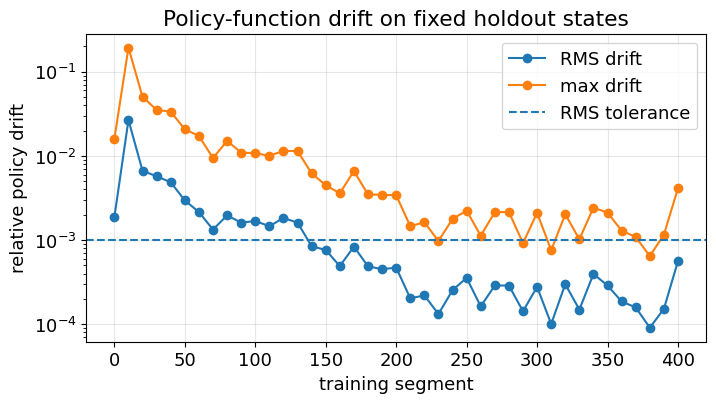

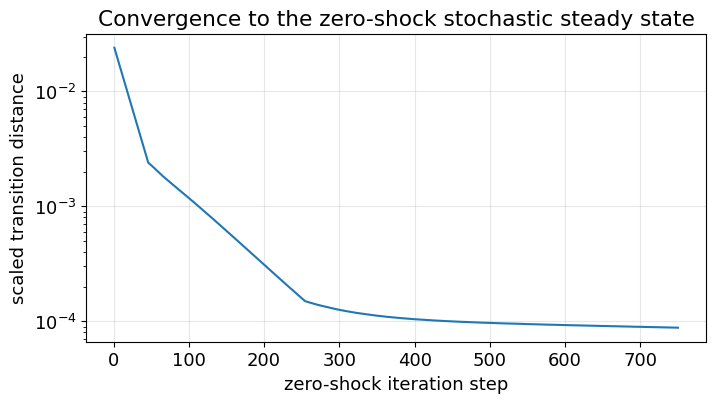

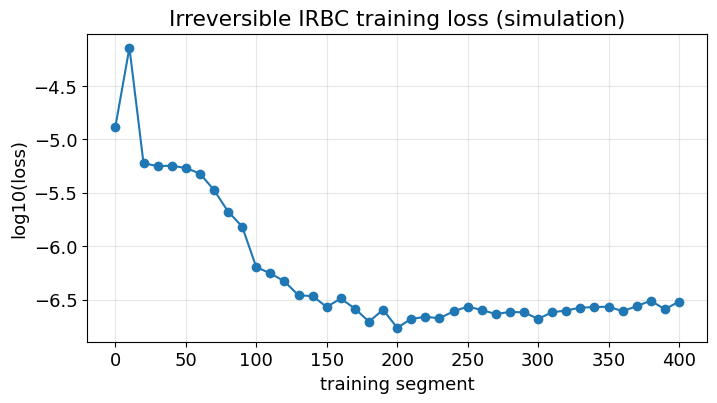

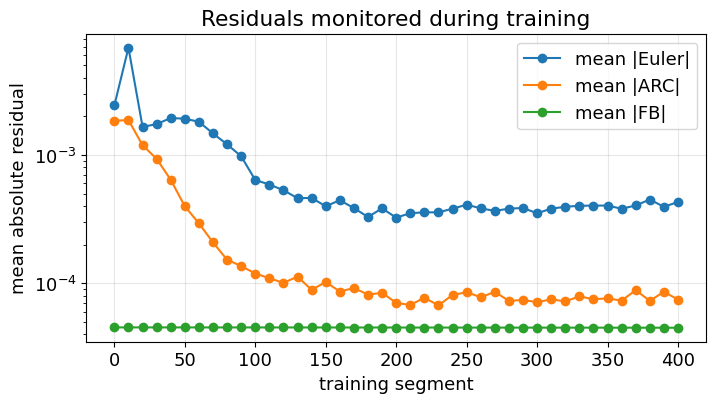

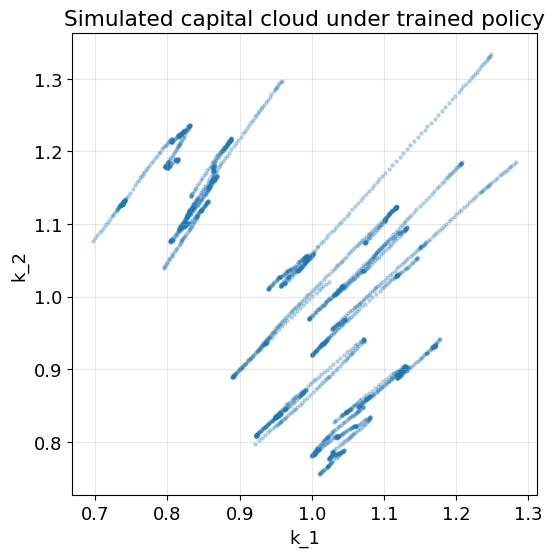

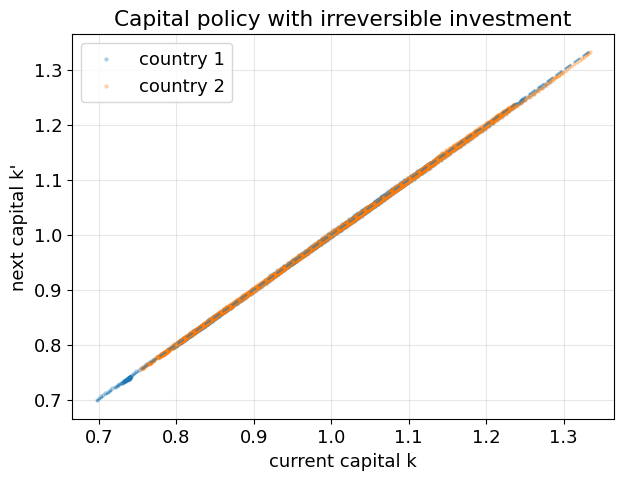

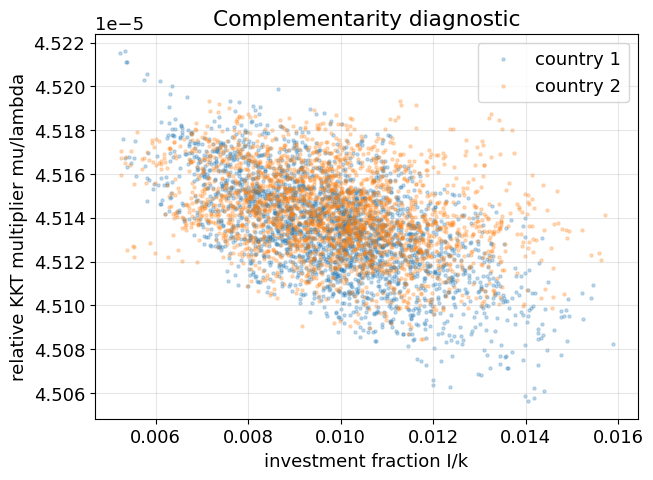

In [10]:

if len(history.get("policy_drift_rms", [])) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(history["segment"], history["policy_drift_rms"], marker="o", label="RMS drift")
    plt.plot(history["segment"], history["policy_drift_max"], marker="o", label="max drift")
    plt.axhline(TIME_INVARIANCE_TOL_RMS, linestyle="--", label="RMS tolerance")
    plt.yscale("log")
    plt.xlabel("training segment")
    plt.ylabel("relative policy drift")
    plt.title("Policy-function drift on fixed holdout states")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if isinstance(globals().get("zero_shock_result"), dict) and len(zero_shock_result["distances"]) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(zero_shock_result["distances"]) + 1), zero_shock_result["distances"])
    plt.yscale("log")
    plt.xlabel("zero-shock iteration step")
    plt.ylabel("scaled transition distance")
    plt.title("Convergence to the zero-shock stochastic steady state")
    plt.grid(True, alpha=0.3)
    plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["segment"], np.log10(np.maximum(history["loss"], 1e-30)), marker="o")
plt.xlabel("training segment")
plt.ylabel("log10(loss)")
plt.title(f"Irreversible IRBC training loss ({SAMPLING_MODE})")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["segment"], history["mean_abs_euler"], marker="o", label="mean |Euler|")
plt.plot(history["segment"], history["mean_abs_arc"], marker="o", label="mean |ARC|")
plt.plot(history["segment"], history["mean_abs_fb"], marker="o", label="mean |FB|")
plt.yscale("log")
plt.xlabel("training segment")
plt.ylabel("mean absolute residual")
plt.title("Residuals monitored during training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

X_cloud = simulated_evaluation_states(model, n_eval_tracks=10, burn_in=32, eval_length=256)
X_cloud_np = X_cloud.numpy()
kp_cloud, lambda_cloud, mu_cloud, I_cloud, Ifrac_cloud = policy(X_cloud, model)

if N_COUNTRIES >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(X_cloud_np[:, 0], X_cloud_np[:, 1], s=5, alpha=0.25)
    plt.xlabel("k_1")
    plt.ylabel("k_2")
    plt.title("Simulated capital cloud under trained policy")
    plt.grid(True, alpha=0.3)
    plt.show()

plt.figure(figsize=(7, 5))
for j in range(N_COUNTRIES):
    plt.scatter(X_cloud_np[:, j], kp_cloud.numpy()[:, j], s=5, alpha=0.25, label=f"country {j+1}")
lo = min(X_cloud_np[:, :N_COUNTRIES].min(), kp_cloud.numpy().min())
hi = max(X_cloud_np[:, :N_COUNTRIES].max(), kp_cloud.numpy().max())
plt.plot([lo, hi], [lo, hi], "--", alpha=0.6)
plt.xlabel("current capital k")
plt.ylabel("next capital k'")
plt.title("Capital policy with irreversible investment")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
for j in range(N_COUNTRIES):
    plt.scatter(Ifrac_cloud.numpy()[:, j], mu_cloud.numpy()[:, j] / lambda_cloud.numpy()[:, 0], s=5, alpha=0.25, label=f"country {j+1}")
plt.xlabel("investment fraction I/k")
plt.ylabel("relative KKT multiplier mu/lambda")
plt.title("Complementarity diagnostic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 10. How to change the training data and optimizer

To use one long trajectory, set
```python
N_TRAJECTORIES = 1
SIMULATION_LENGTH = 1024
```
To use several shorter trajectories, set
```python
N_TRAJECTORIES = 10
SIMULATION_LENGTH = 256
```
To switch to exogenous sampling, set
```python
SAMPLING_MODE = "exogenous"
```
To change the optimizer, edit `OPTIMIZER_NAME`, `LEARNING_RATE`, `BATCH_SIZE`, and `PASSES_PER_SEGMENT` in the first code cell.

The policy-stability check is controlled by `TIME_INVARIANCE_ANCHOR_STATES`, `TIME_INVARIANCE_TOL_RMS`, and `TIME_INVARIANCE_TOL_MAX`. The zero-shock stochastic steady-state check is controlled by `RUN_ZERO_SHOCK_STEADY_STATE_CHECK`, `ZERO_SHOCK_N_STARTS`, `ZERO_SHOCK_MAX_STEPS`, and `ZERO_SHOCK_TOL`.